### **Feature selection using GWO**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('/content/All_hrv_features.csv')
X = data.drop(columns=['File_Name', 'Label'])
y = data['Label']
X.dropna(inplace=True)
y = y[X.index]

In [ ]:
import numpy as np
import random

class GreyWolfOptimizer:
    def __init__(self, num_agents, max_iter, num_features):
        self.num_agents = num_agents
        self.max_iter = max_iter
        self.num_features = num_features
        self.alpha_pos = np.zeros(num_features)
        self.beta_pos = np.zeros(num_features)
        self.delta_pos = np.zeros(num_features)
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')
        self.positions = np.random.randint(2, size=(num_agents, num_features))

    def fitness(self, position, X_train, y_train, X_val, y_val):
        selected_features = np.where(position == 1)[0]
        if len(selected_features) == 0:
            return float('inf')
        X_train_fs = X_train[:, selected_features]
        X_val_fs = X_val[:, selected_features]
        model = KNeighborsClassifier(n_neighbors=3)
        model.fit(X_train_fs, y_train)
        y_pred = model.predict(X_val_fs)
        return 1.0 - accuracy_score(y_val, y_pred)

    def update_position(self, X_train, y_train, X_val, y_val):
        for i in range(self.num_agents):
            fitness = self.fitness(self.positions[i], X_train, y_train, X_val, y_val)
            if fitness < self.alpha_score:
                self.delta_score = self.beta_score
                self.delta_pos = self.beta_pos.copy()
                self.beta_score = self.alpha_score
                self.beta_pos = self.alpha_pos.copy()
                self.alpha_score = fitness
                self.alpha_pos = self.positions[i].copy()
            elif fitness < self.beta_score:
                self.delta_score = self.beta_score
                self.delta_pos = self.beta_pos.copy()
                self.beta_score = fitness
                self.beta_pos = self.positions[i].copy()
            elif fitness < self.delta_score:
                self.delta_score = fitness
                self.delta_pos = self.positions[i].copy()

    def optimize(self, X_train, y_train, X_val, y_val):
        for t in range(self.max_iter):
            a = 2 - t * (2 / self.max_iter)
            for i in range(self.num_agents):
                for j in range(self.num_features):
                    r1, r2 = random.random(), random.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * self.alpha_pos[j] - self.positions[i, j])
                    X1 = self.alpha_pos[j] - A1 * D_alpha

                    r1, r2 = random.random(), random.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * self.beta_pos[j] - self.positions[i, j])
                    X2 = self.beta_pos[j] - A2 * D_beta

                    r1, r2 = random.random(), random.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * self.delta_pos[j] - self.positions[i, j])
                    X3 = self.delta_pos[j] - A3 * D_delta

                    self.positions[i, j] = (X1 + X2 + X3) / 3
                    if random.random() > 0.5:
                        self.positions[i, j] = 1
                    else:
                        self.positions[i, j] = 0

                self.update_position(X_train, y_train, X_val, y_val)

        return self.alpha_pos

### **KNeighborsClassifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = X.shape[1]
gwo = GreyWolfOptimizer(num_agents=10, max_iter=20, num_features=num_features)
best_features = gwo.optimize(X_train.values, y_train.values, X_val.values, y_val.values)

selected_features = np.where(best_features == 1)[0]
X_train_fs = X_train.iloc[:, selected_features]
X_val_fs = X_val.iloc[:, selected_features]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_fs, y_train)
y_pred = model.predict(X_val_fs)

accuracy = accuracy_score(y_val, y_pred)
print(f'GWO Selected Features: {selected_features}')
print(f'Accuracy with GWO Selected Features: {accuracy}')

GWO Selected Features: [ 3  4  5  8 10 12 13 14 15 20 22 25 26 30 35 36 37 41 44 49 50 56 58 59
 60 62 63 64 66 72 74 75 76 77 79 83]
Accuracy with GWO Selected Features: 0.9090909090909091


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = X.shape[1]
gwo = GreyWolfOptimizer(num_agents=10, max_iter=20, num_features=num_features)
best_features = gwo.optimize(X_train.values, y_train.values, X_val.values, y_val.values)

selected_features_indices = np.where(best_features == 1)[0]
selected_features = X.columns[selected_features_indices]
X_train_fs = X_train.iloc[:, selected_features_indices]
X_val_fs = X_val.iloc[:, selected_features_indices]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_fs, y_train)
y_pred = model.predict(X_val_fs)

accuracy = accuracy_score(y_val, y_pred)
print(f'GWO Selected Features: {selected_features}')
print(f'Accuracy with GWO Selected Features: {accuracy}')
selected_data = data[['File_Name', 'Label'] + list(selected_features)]
selected_data.to_csv('selected_features.csv', index=False)

GWO Selected Features: Index(['HRV_SDSD', 'HRV_MedianNN', 'HRV_Prc20NN', 'HRV_CVNN', 'HRV_CVSD',
       'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_TINN', 'HRV_TP',
       'HRV_HFn', 'HRV_LnHF', 'HRV_SD1', 'HRV_PIP', 'HRV_IALS', 'HRV_PSS',
       'HRV_SI', 'HRV_AI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_C2a',
       'HRV_SD2d', 'HRV_Cd', 'HRV_SDNNd', 'HRV_DFA_alpha1',
       'HRV_MFDFA_alpha1_Width', 'HRV_MFDFA_alpha1_Mean',
       'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Increment', 'HRV_SampEn',
       'HRV_MSEn', 'HRV_CD', 'HRV_HFD', 'HRV_KFD', 'HRV_DFA_alpha2',
       'HRV_MFDFA_alpha2_Width', 'HRV_MFDFA_alpha2_Asymmetry',
       'HRV_MFDFA_alpha2_Increment', 'HR'],
      dtype='object')
Accuracy with GWO Selected Features: 0.9090909090909091


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

classification=classification_report(y_val, y_pred)
confusion=confusion_matrix(y_val, y_pred)
print(f'Classification Report:\n {classification}')
print(f'Confusion Matrix:\n {confusion}')

Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.80      0.89         5

    accuracy                           0.91        11
   macro avg       0.93      0.90      0.91        11
weighted avg       0.92      0.91      0.91        11

Confusion Matrix:
 [[6 0]
 [1 4]]


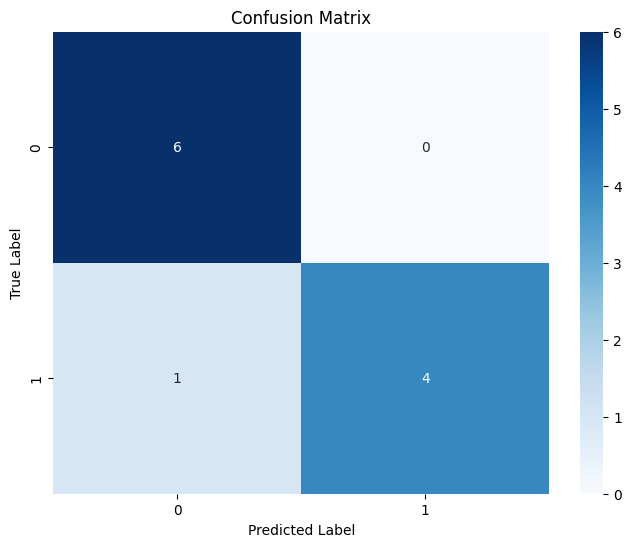

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### **Trying to visualize**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = pd.read_csv('/content/All_hrv_features.csv')
X = data.drop(columns=['File_Name', 'Label'])
y = data['Label']
X.dropna(inplace=True)
y = y[X.index]

In [ ]:
import numpy as np
import random

class GreyWolfOptimizer:
    def __init__(self, num_agents, max_iter, num_features):
        self.num_agents = num_agents
        self.max_iter = max_iter
        self.num_features = num_features
        self.alpha_pos = np.zeros(num_features)
        self.beta_pos = np.zeros(num_features)
        self.delta_pos = np.zeros(num_features)
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')
        self.positions = np.random.randint(2, size=(num_agents, num_features))

    def fitness(self, position, X_train, y_train, X_val, y_val):
        selected_features = np.where(position == 1)[0]
        if len(selected_features) == 0:
            return float('inf')
        X_train_fs = X_train[:, selected_features]
        X_val_fs = X_val[:, selected_features]
        model = KNeighborsClassifier(n_neighbors=3)
        model.fit(X_train_fs, y_train)
        y_pred = model.predict(X_val_fs)
        return 1.0 - accuracy_score(y_val, y_pred)

    def update_position(self, X_train, y_train, X_val, y_val):
        for i in range(self.num_agents):
            fitness = self.fitness(self.positions[i], X_train, y_train, X_val, y_val)
            if fitness < self.alpha_score:
                self.delta_score = self.beta_score
                self.delta_pos = self.beta_pos.copy()
                self.beta_score = self.alpha_score
                self.beta_pos = self.alpha_pos.copy()
                self.alpha_score = fitness
                self.alpha_pos = self.positions[i].copy()
            elif fitness < self.beta_score:
                self.delta_score = self.beta_score
                self.delta_pos = self.beta_pos.copy()
                self.beta_score = fitness
                self.beta_pos = self.positions[i].copy()
            elif fitness < self.delta_score:
                self.delta_score = fitness
                self.delta_pos = self.positions[i].copy()

    def optimize(self, X_train, y_train, X_val, y_val):
        for t in range(self.max_iter):
            a = 2 - t * (2 / self.max_iter)
            for i in range(self.num_agents):
                for j in range(self.num_features):
                    r1, r2 = random.random(), random.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * self.alpha_pos[j] - self.positions[i, j])
                    X1 = self.alpha_pos[j] - A1 * D_alpha

                    r1, r2 = random.random(), random.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * self.beta_pos[j] - self.positions[i, j])
                    X2 = self.beta_pos[j] - A2 * D_beta

                    r1, r2 = random.random(), random.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * self.delta_pos[j] - self.positions[i, j])
                    X3 = self.delta_pos[j] - A3 * D_delta

                    self.positions[i, j] = (X1 + X2 + X3) / 3
                    if random.random() > 0.5:
                        self.positions[i, j] = 1
                    else:
                        self.positions[i, j] = 0

                self.update_position(X_train, y_train, X_val, y_val)

        return self.alpha_pos

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = X.shape[1]
gwo = GreyWolfOptimizer(num_agents=40, max_iter=80, num_features=num_features)
best_features = gwo.optimize(X_train.values, y_train.values, X_val.values, y_val.values)

selected_features_indices = np.where(best_features == 1)[0]
selected_features = X.columns[selected_features_indices]
X_train_fs = X_train.iloc[:, selected_features_indices]
X_val_fs = X_val.iloc[:, selected_features_indices]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_fs, y_train)
y_pred = model.predict(X_val_fs)

accuracy = accuracy_score(y_val, y_pred)
print(f'GWO Selected Features: {selected_features}')
print(f'Accuracy with GWO Selected Features: {accuracy}')
selected_data = data[['File_Name', 'Label'] + list(selected_features)]
selected_data.to_csv('selected_features.csv', index=False)

GWO Selected Features: Index(['HRV_MeanNN', 'HRV_MedianNN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_HF',
       'HRV_MinNN', 'HRV_TINN', 'HRV_VLF', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn',
       'HRV_LnHF', 'HRV_CSI', 'HRV_CVI', 'HRV_PIP', 'HRV_PAS', 'HRV_GI',
       'HRV_PI', 'HRV_C1d', 'HRV_C1a', 'HRV_SD1d', 'HRV_SD1a', 'HRV_C2a',
       'HRV_SD2a', 'HRV_Cd', 'HRV_SDNNa', 'HRV_MFDFA_alpha1_Mean',
       'HRV_MFDFA_alpha1_Max', 'HRV_MFDFA_alpha1_Asymmetry',
       'HRV_MFDFA_alpha1_Fluctuation', 'HRV_MFDFA_alpha1_Increment',
       'HRV_SampEn', 'HRV_ShanEn', 'HRV_CMSEn', 'HRV_RCMSEn', 'HRV_HFD',
       'HRV_MFDFA_alpha2_Mean', 'HRV_MFDFA_alpha2_Max',
       'HRV_MFDFA_alpha2_Delta', 'HRV_MFDFA_alpha2_Increment', 'HR'],
      dtype='object')
Accuracy with GWO Selected Features: 0.9090909090909091


                              HRV_MeanNN  HRV_MedianNN  HRV_pNN50  HRV_pNN20  \
HRV_MeanNN                      1.000000      0.995899   0.648841   0.796735   
HRV_MedianNN                    0.995899      1.000000   0.661727   0.796340   
HRV_pNN50                       0.648841      0.661727   1.000000   0.892712   
HRV_pNN20                       0.796735      0.796340   0.892712   1.000000   
HRV_HF                          0.128144      0.149889   0.429297   0.304569   
HRV_MinNN                       0.040738      0.016889  -0.177852  -0.084459   
HRV_TINN                        0.601175      0.622135   0.489670   0.516468   
HRV_VLF                         0.030353      0.007989  -0.053451  -0.066408   
HRV_LFHF                       -0.020406     -0.026626  -0.332567  -0.243968   
HRV_LFn                        -0.012749     -0.019526  -0.321700  -0.212341   
HRV_HFn                         0.073426      0.082023   0.393939   0.295393   
HRV_LnHF                        0.151315

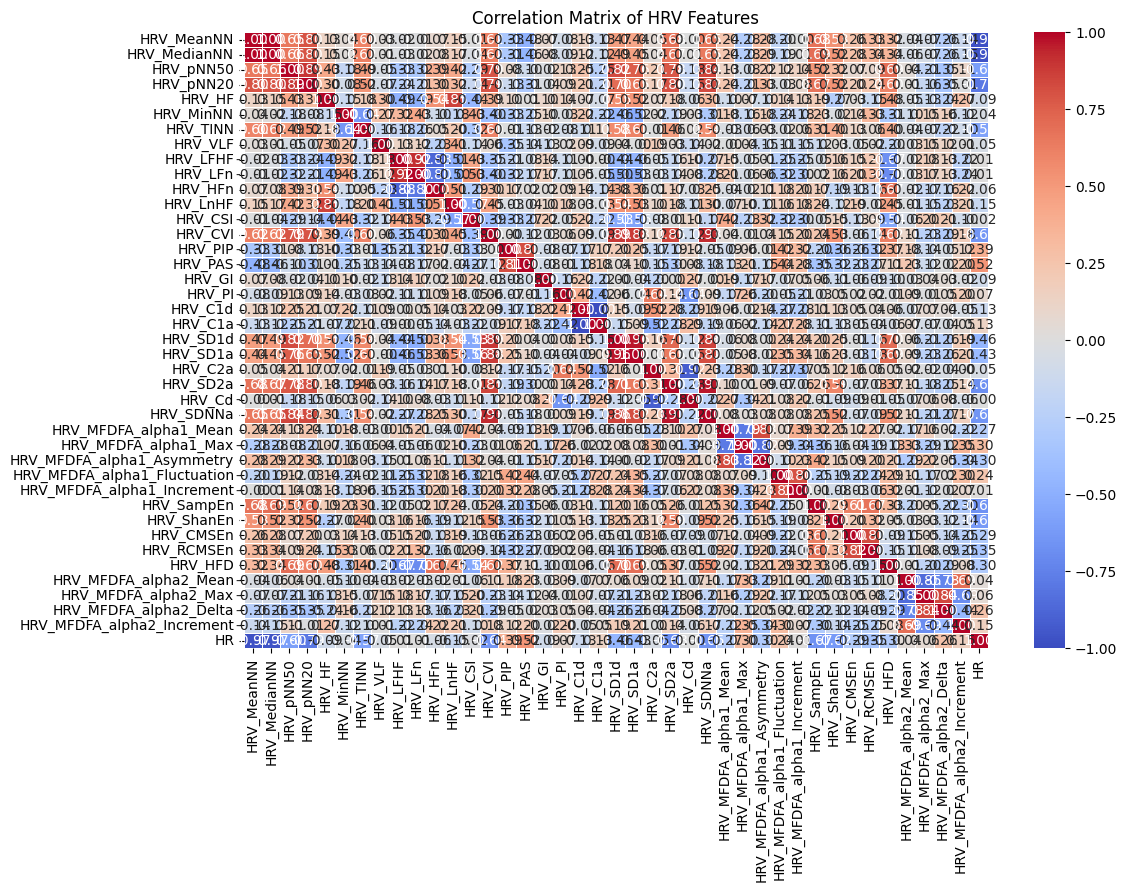

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data_file=pd.read_csv('/content/selected_features.csv')
data=data_file.iloc[:,2:]
correlation_matrix = data.corr()
print(correlation_matrix)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of HRV Features')
plt.show()

### **Convergence curve**

GWO Selected Features: [ 0  7  8  9 10 13 16 19 20 21 23 25 26 39 42 43 46 47 48 52 54 55 60 61
 63 64 67 69 70 72 74 76 77 78 79 81]
Accuracy with GWO Selected Features: 0.9090909090909091


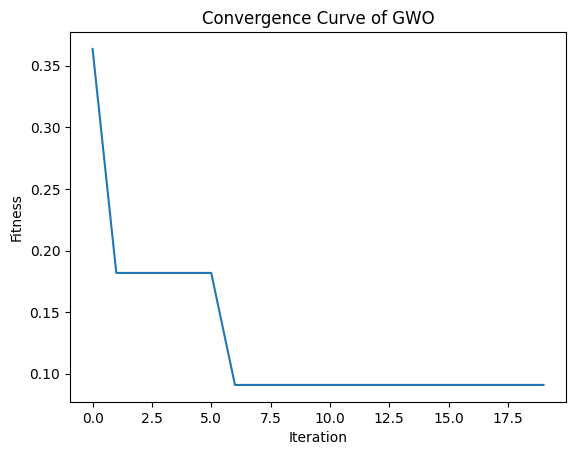

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import random
import matplotlib.pyplot as plt

class GreyWolfOptimizer:
    def __init__(self, num_agents, max_iter, num_features):
        self.num_agents = num_agents
        self.max_iter = max_iter
        self.num_features = num_features
        self.alpha_pos = np.zeros(num_features)
        self.beta_pos = np.zeros(num_features)
        self.delta_pos = np.zeros(num_features)
        self.alpha_score = float('inf')
        self.beta_score = float('inf')
        self.delta_score = float('inf')
        self.positions = np.random.randint(2, size=(num_agents, num_features))
        self.convergence_curve = []

    def fitness(self, position, X_train, y_train, X_val, y_val):
        selected_features = np.where(position == 1)[0]
        if len(selected_features) == 0:
            return float('inf')
        X_train_fs = X_train[:, selected_features]
        X_val_fs = X_val[:, selected_features]
        model = KNeighborsClassifier(n_neighbors=3)
        model.fit(X_train_fs, y_train)
        y_pred = model.predict(X_val_fs)
        return 1.0 - accuracy_score(y_val, y_pred)

    def update_position(self, X_train, y_train, X_val, y_val):
        for i in range(self.num_agents):
            fitness = self.fitness(self.positions[i], X_train, y_train, X_val, y_val)
            if fitness < self.alpha_score:
                self.delta_score = self.beta_score
                self.delta_pos = self.beta_pos.copy()
                self.beta_score = self.alpha_score
                self.beta_pos = self.alpha_pos.copy()
                self.alpha_score = fitness
                self.alpha_pos = self.positions[i].copy()
            elif fitness < self.beta_score:
                self.delta_score = self.beta_score
                self.delta_pos = self.beta_pos.copy()
                self.beta_score = fitness
                self.beta_pos = self.positions[i].copy()
            elif fitness < self.delta_score:
                self.delta_score = fitness
                self.delta_pos = self.positions[i].copy()

    def optimize(self, X_train, y_train, X_val, y_val):
        for t in range(self.max_iter):
            a = 2 - t * (2 / self.max_iter)
            for i in range(self.num_agents):
                for j in range(self.num_features):
                    r1, r2 = random.random(), random.random()
                    A1 = 2 * a * r1 - a
                    C1 = 2 * r2
                    D_alpha = abs(C1 * self.alpha_pos[j] - self.positions[i, j])
                    X1 = self.alpha_pos[j] - A1 * D_alpha

                    r1, r2 = random.random(), random.random()
                    A2 = 2 * a * r1 - a
                    C2 = 2 * r2
                    D_beta = abs(C2 * self.beta_pos[j] - self.positions[i, j])
                    X2 = self.beta_pos[j] - A2 * D_beta

                    r1, r2 = random.random(), random.random()
                    A3 = 2 * a * r1 - a
                    C3 = 2 * r2
                    D_delta = abs(C3 * self.delta_pos[j] - self.positions[i, j])
                    X3 = self.delta_pos[j] - A3 * D_delta

                    self.positions[i, j] = (X1 + X2 + X3) / 3
                    if random.random() > 0.5:
                        self.positions[i, j] = 1
                    else:
                        self.positions[i, j] = 0

                self.update_position(X_train, y_train, X_val, y_val)

            self.convergence_curve.append(self.alpha_score)

        return self.alpha_pos

data = pd.read_csv('/content/All_hrv_features.csv')
X = data.drop(columns=['File_Name', 'Label'])
y = data['Label']
X.dropna(inplace=True)
y = y[X.index]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

num_features = X.shape[1]
gwo = GreyWolfOptimizer(num_agents=10, max_iter=20, num_features=num_features)
best_features = gwo.optimize(X_train.values, y_train.values, X_val.values, y_val.values)

selected_features = np.where(best_features == 1)[0]
X_train_fs = X_train.iloc[:, selected_features]
X_val_fs = X_val.iloc[:, selected_features]

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_fs, y_train)
y_pred = model.predict(X_val_fs)

accuracy = accuracy_score(y_val, y_pred)
print(f'GWO Selected Features: {selected_features}')
print(f'Accuracy with GWO Selected Features: {accuracy}')

#convergence curve
plt.plot(gwo.convergence_curve)
plt.title('Convergence Curve of GWO')
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.show()